Table de contigence
Allergies  None  Peanuts  Penicillin  Pollen
BloodType                                   
A+          446      500         510     508
A-          498      448         514     512
AB+         428      498         506     472
AB-         444      476         506     508
B+          520      488         512     424
B-          504      528         512     474
O+          502      500         452     520
O-          472      438         468     468

Statistique chi2: 42.82
p-value: 0.0033
=>Association significative entre le groupe sanguin et les allergies


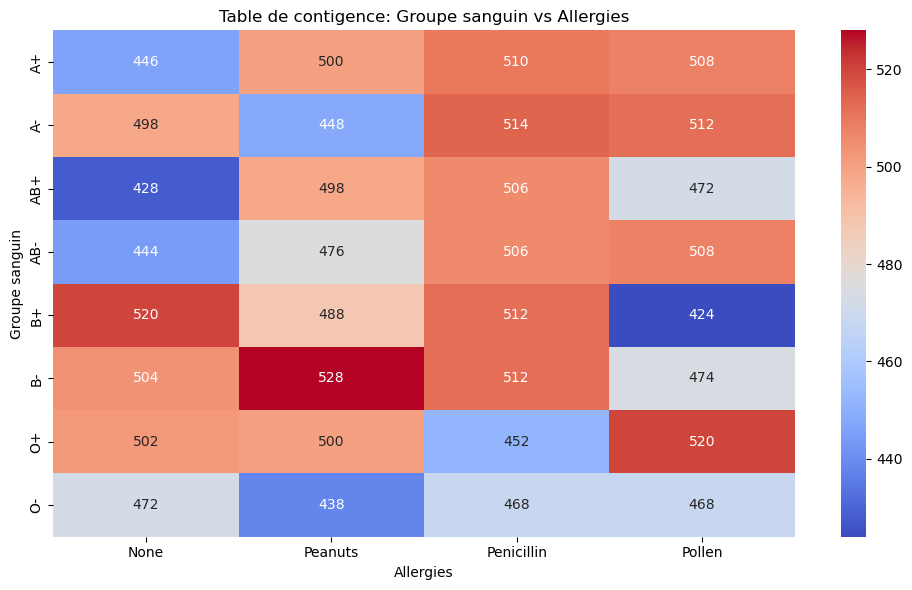

In [1]:
import pandas as pd
from datetime import datetime
from dotenv import load_dotenv
# Connexion à SQL Server
from sqlalchemy import create_engine
import urllib
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os

# Recharger variables d'envronnements
load_dotenv(override=True)
#1. Chemin du repertoire dans lequel se trouve le fichier
sys.path.append(os.getenv("DBCONNECT_PARENT"))  # The parent of `dbconnect`
#2. Module pour la connection à Sqlserver
from dbconnect.connection import SQLServerConnector
# 2.1 Récupération des paramètres de connection
conn = SQLServerConnector()
# print(conn.get_connection_string())
# Build connection string
conn_str = conn.get_connection_string()
params = urllib.parse.quote_plus(conn_str)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")
#Requête SQL 
query = "SELECT BloodType,Allergies FROM health.dbo.Patients"
df = pd.read_sql(query, con=engine)

#Analyse statistique avec le test du chi2
from scipy.stats import chi2_contingency
#Table de contigence
contigence= pd.crosstab(df['BloodType'],df['Allergies'])
print("Table de contigence")
print(contigence)

#Test du chi2
chi2, p, dof, expected = chi2_contingency(contigence)
print(f"\nStatistique chi2: {chi2:.2f}")
print(f"p-value: {p:.4f}")
if p < 0.05:
    print("=>Association significative entre le groupe sanguin et les allergies")
else:
    print("=>Aucune association trouvée.")
    
plt.figure(figsize=(10, 6))
sns.heatmap(contigence, annot=True, fmt='d', cmap='coolwarm')
plt.title("Table de contigence: Groupe sanguin vs Allergies")
plt.xlabel("Allergies")
plt.ylabel("Groupe sanguin")
plt.tight_layout()
plt.show()



